# **DO NOT EDIT THIS NOTEBOOK TO AVOID CONFLICTS WHEN PUSHING/PULLING**

# **S24 Pipeline v2**

In [1]:
# sys.path.insert(0, "/home/ang/usd_ang/lib/python")
# os.environ["LD_LIBRARY_PATH"] = "/home/ang/usd_ang/lib"

In [2]:
from S24.pipeline.sysml_pipeline_runner import run_sysml_to_json_pipeline

result = run_sysml_to_json_pipeline(
    sysml_file="ECLIPSE_Project2.sysml",
    verbose=1,
)


[WRITE] Full JSON → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project2/ECLIPSE_Project2.json

[METADATA]
{
  "package": "ECLIPSE_LSP1",
  "num_parts": 5,
  "num_connections": 2,
  "validation_errors": []
}
[SUMMARY] Wrote 5 part files
[WRITE] HabitationModule → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project2/assets/HabitationModule.json
[WRITE] ISRU_PLANT → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project2/assets/ISRU_PLANT.json
[WRITE] landing_site → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project2/assets/landing_site.json
[WRITE] Propellant_Depot → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project2/assets/Propellant_Depot.json
[WRITE] Rover → /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/

In [3]:
from typing import Dict, Any, List, Optional

from S24.sysml.interfaces import build_system_graph
from S24.validation.plotter import plot_system_graph


def run_connectivity_graph(
    data: Dict[str, Any],
    *,
    active_nodes: Optional[List[str]] = None,
    json_asset_paths: Optional[List[str]] = None,
    verbose: int = 2,
) -> Dict[str, Any]:
    """
    Build and optionally filter a system connectivity graph.

    Parameters
    ----------
    data : Dict[str, Any]
        Full system data (output of sysml_to_json_transformer)

    active_nodes : Optional[List[str]]
        Subset of nodes to activate. If None → all nodes are used.

    json_asset_paths : Optional[List[str]]
        Paths to per-part JSON files (used to map active nodes → files)

    verbose : int
        0 → no prints / no plots
        1 → summary prints
        2 → detailed prints + plotting

    Returns
    -------
    Dict containing:
        - active_nodes (dict)
        - graph (networkx.DiGraph)
        - connections (filtered)
        - asset_paths (filtered if provided)
    """

    parts = data["parts"]
    connections = data["connections"]

    if active_nodes is None:
        active_nodes = [p["name"] for p in parts]

    active_set = set(active_nodes)


    filtered_parts = [
        p for p in parts if p["name"] in active_set
    ]

    filtered_connections = [
        c for c in connections
        if c["from"]["part"] in active_set
        and c["to"]["part"] in active_set
    ]

    G = build_system_graph(filtered_parts, filtered_connections)

    filtered_asset_paths = None

    if json_asset_paths is not None:
        filtered_asset_paths = [
            path for path in json_asset_paths
            if any(node in str(path) for node in active_set)
        ]

    if verbose >= 1:
        print(f"[GRAPH] Active nodes: {len(filtered_parts)} / {len(parts)}")
        print(f"[GRAPH] Active connections: {len(filtered_connections)} / {len(connections)}")

    if verbose >= 2:
        print("\n[ACTIVE CONNECTIONS]")
        for c in filtered_connections:
            print(c)

        print("\n[GRAPH OBJECT]")
        print(G)

        plot_system_graph(G)


    return {
        "active_nodes": {
            "list": active_nodes,
            "count": len(filtered_parts),
        },
        "graph": G,
        "connections": filtered_connections,
        "asset_paths": filtered_asset_paths,
    }

## **Node activation: Mission Network Activation**

[GRAPH] Active nodes: 5 / 5
[GRAPH] Active connections: 2 / 2

[ACTIVE CONNECTIONS]
{'name': 'ISRUPlantToRover', 'type': 'LOXMovement', 'flow': 'LOXMOVEMENT', 'from': {'part': 'ISRU_PLANT', 'port': 'ISRU_LOXPortOut'}, 'to': {'part': 'Rover', 'port': 'RoverFleet_LOXPortInOut'}}
{'name': 'RoverToPropellantDepot', 'type': 'LOXMovement', 'flow': 'LOXMOVEMENT', 'from': {'part': 'Rover', 'port': 'RoverFleet_LOXPortInOut'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_LOXPortIn'}}

[GRAPH OBJECT]
DiGraph with 5 nodes and 2 edges


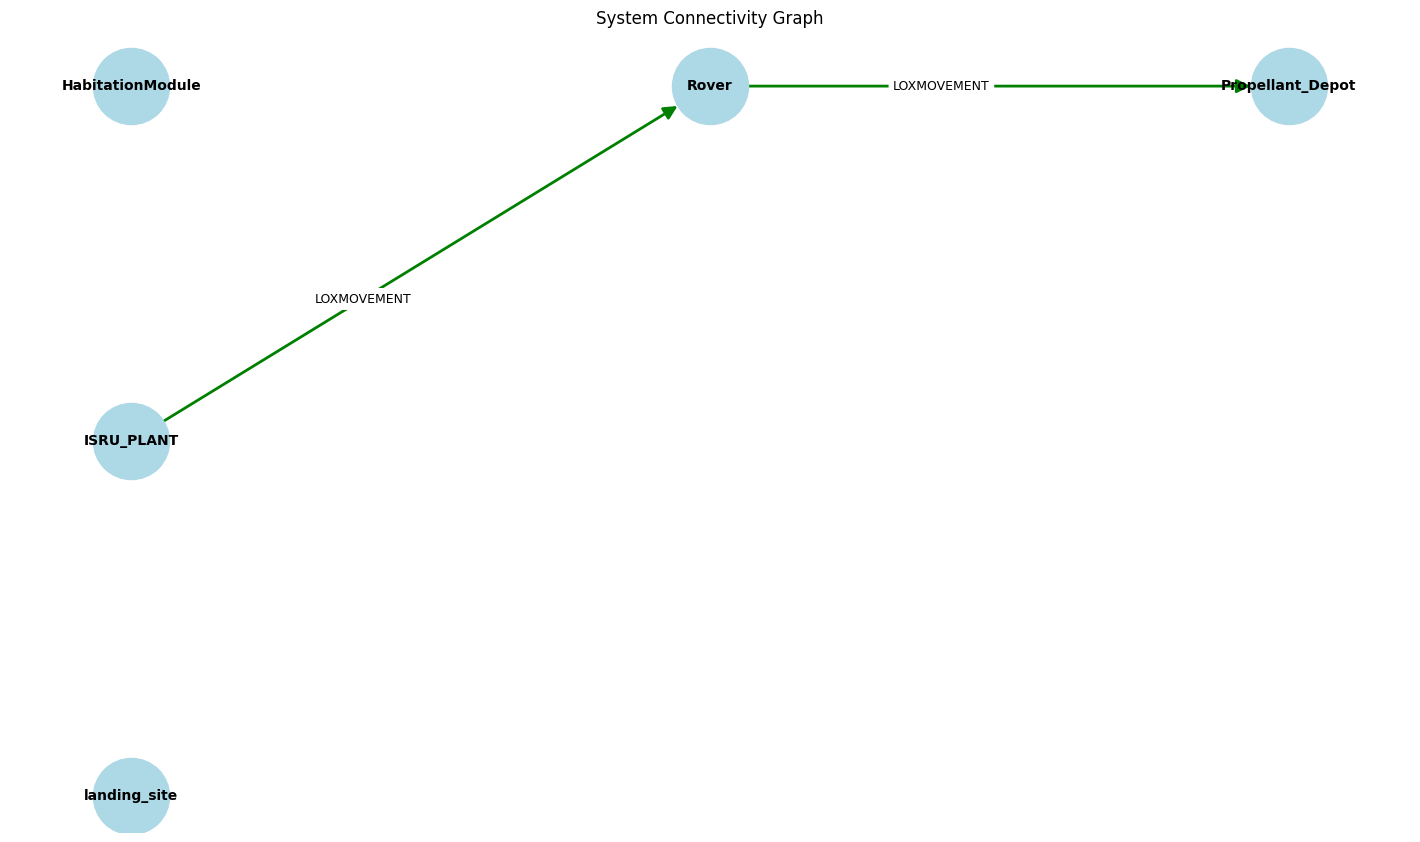

In [4]:
active_nodes = [
    "ISRU_PLANT",
    "Rover",
    "Propellant_Depot"
] 

asset_paths = result['paths']['assets']
data0 = run_connectivity_graph(data=result['data'], active_nodes=None, json_asset_paths=asset_paths)

In [5]:
# from S24.sysml.interfaces import build_system_graph

# data = result['data']
# parts = data["parts"]
# connections = data["connections"]

# G = build_system_graph(parts, connections)
# print(G)

# print("\n[CONNECTIONS]")
# for c in connections:
#     print(c)


# from S24.validation.plotter import plot_system_graph
# plot_system_graph(G)

# active_nodes = [
#     "ISRU_PLANT",
#     "Rover",
#     "Propellant_Depot"
# ] 

# active_data = activate_subsystem(
#     result["data"],
#     active_nodes,
#     verbose=2
# )

# G_active = build_system_graph(
#     active_data["parts"],
#     active_data["connections"]
# )

# plot_system_graph(G_active)

## **DES** 

Slider value dict is expected to come from the user entering values on the HTML

In [6]:
# from S24.DES_pipeline_version import run_scenario

# slider_value_dict = {
#     "Num_Regolith_Rovers": 3,
#     "Num_ISRU_Plants": 2,
#     "Regolith_Haul_Distance": 1, #km
#     "LOX_Haul_Distance": 1, #km
#     "Rover_Energy_Consumption": 0.00034, #kWh/km/kg, Energy Per Kilometer Per Kilogram of Payload, supposed to replace the "Rover discharge rate" slider value
#     "Rover_Travel_Time": 5, #hr/km
#     "ISRU_Plant_Processing_Rate": 1600, #kg/hr
#     "LOX_Transport_Threshold": 100, #kg, the amount of LOX at which the LOX rover will take the LOX at the ISRU plant and transport it to the launch and landing zone.
# }

# run_scenario(slider_value_dict)

## **Turn JSON into an structured python object and vet json graph validity and entries for usd**

In [7]:
# from S24.jsonio import VettingProc

# vetting = VettingProc(source=str(JSON_FILE))
# vetted_parts = vetting.by_name

# list(vetted_parts.keys())

In [8]:
# from S24.usd import USDBuilder

# builder = USDBuilder(
#     vetted_parts,
#     overwrite=True,
#     use_paths_from_vetted=False
# )

# outputs = builder.build_all_parts()
# outputs

# scene_path = builder.write_assembly_scene(
#     root_name="HabitationModule",
#     include_root_as_instance=True,
#     instanceable=False,
#     debug_refs=True
# )

# scene_path